In [1]:
## Installing required library

!pip install sentence-transformers seaborn matplotlib

In [2]:
## Creating 10 sentences (3 topics)

sentences = [
    # Cricket (4)
    "The batsman scored a 100 runs in the semi final match",
    "The batsman took a 6's hat-trick in the final over",
    "The team won the match by chasing a huge target",
    "Fielders catches were the best catches ever in the history of the cricket",

    # Cooking (3)
    "The chef prepared a delicious salad with fresh vegetables",
    "Baking a cake requires precise measurements and timing",
    "Indian spices are best that adds extra flavor and aroma to the any dish",

    # Cybersecurity (3)
    "Passwords to be replaced every month to avoid hacking and it must be alphanumeric strong passwords",
    "Firewalls prevent unauthorized access to networks",
    "Cyber crimes are increasing day by day and so is the cybersecurity developments"
]

In [3]:
## Generating embeddings

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
## Cosine similarity matrix

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

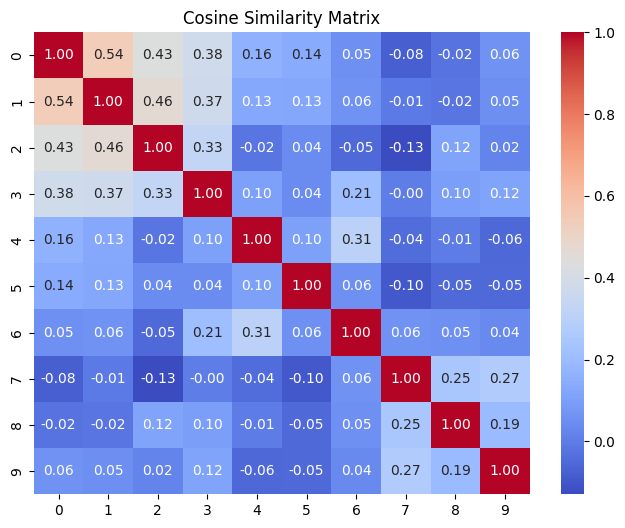

In [6]:
## Display heatmap (10×10)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
## Query sentence similarity

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

In [8]:
## Find top 2 similar sentences

import numpy as np

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(similarities)[-2:][::-1]

print("Top 2 similar sentences:\n")
for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Top 2 similar sentences:

Sentence: The batsman took a 6's hat-trick in the final over
Similarity Score: 0.5943

Sentence: The batsman scored a 100 runs in the semi final match
Similarity Score: 0.5592

